<a href="https://colab.research.google.com/github/ADA-CompVision/SDP2022-brstcancer/blob/ralili/GAN/gan_models_test_155_epochs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import argparse
import os
import numpy as np
import math
import sys

import torchvision.transforms as transforms
from torchvision.utils import save_image

from torch.utils.data import DataLoader, Dataset
from PIL import Image
from torchvision import datasets
from torch.autograd import Variable

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
GPU name: Tesla T4


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "gpu")

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rumiyyaalili","key":"5a48756827bd010b7b5a1f5561da34e8"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d rumiyyaalili/breast-cancer-dataset-merged

Dataset URL: https://www.kaggle.com/datasets/rumiyyaalili/breast-cancer-dataset-merged
License(s): unknown
100% 0.98G/0.98G [00:51<00:00, 21.9MB/s]
100% 0.98G/0.98G [00:51<00:00, 20.3MB/s]


In [ ]:
!unzip -qq breast-cancer-dataset-merged

In [ ]:
# Create directories
os.makedirs("images", exist_ok=True)

In [ ]:
import os

dataset_path = "/content"
extensions = (".png", ".jpg", ".jpeg")

# Count all image files recursively
total_images = 0
for root, _, files in os.walk(dataset_path):
    total_images += sum(file.lower().endswith(extensions) for file in files)

print(f"Total number of images in the dataset: {total_images}")

Total number of images in the dataset: 57755


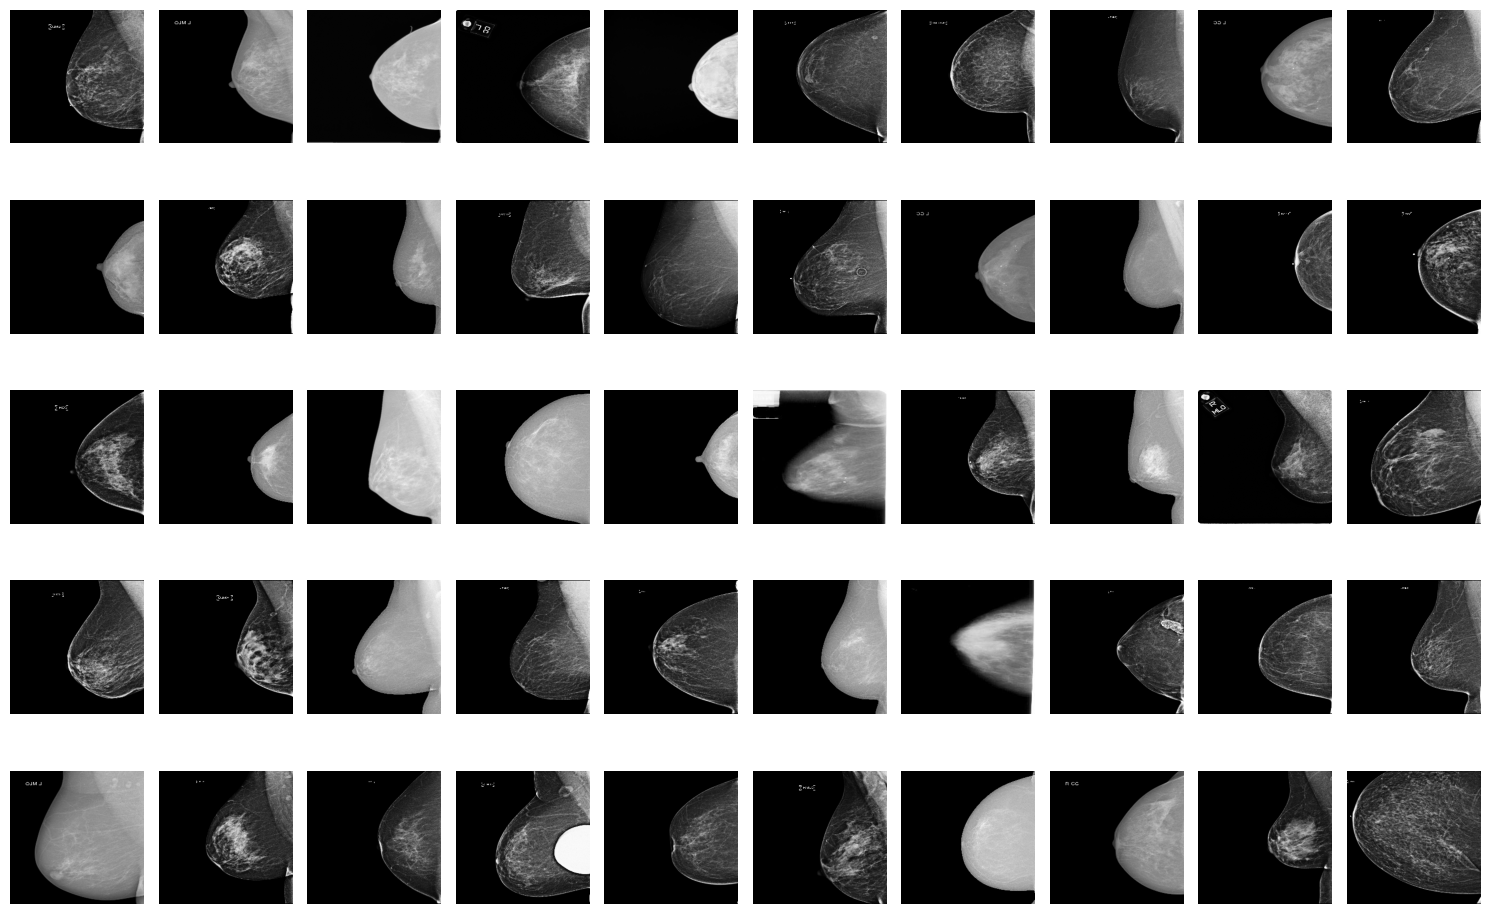

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "/content"
extensions = (".png", ".jpg", ".jpeg")

# Get the first 50 image file paths
image_files = []
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(extensions):
            image_files.append(os.path.join(root, file))
        if len(image_files) >= 50:  # Stop after collecting 50 images
            break
    if len(image_files) >= 50:
        break

# Display the first 50 images
fig, axes = plt.subplots(5, 10, figsize=(15, 10))  # Create a 5x10 grid
axes = axes.flatten()

for img_path, ax in zip(image_files, axes):
    img = Image.open(img_path).convert("L")  # Convert to grayscale
    ax.imshow(img, cmap="gray")  # Display as grayscale
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Set parameters
n_epochs = 150  # Number of epochs of training
batch_size = 64  # Size of the batches
lr_g = 0.0002  # Adam: learning rate for generator
lr_d = 0.00005 # learning rate for discriminator was 0.001
b1 = 0.9  # Adam: decay of first-order momentum of gradient
b2 = 0.999  # Adam: decay of second-order momentum of gradient
latent_dim = 200  # Dimensionality of the latent space was 256
img_size = 256  # Size of each image dimension
channels = 1  # Number of image channels (grayscale)
n_critic = 5  # Number of training steps for discriminator per iteration reduced to 5
#clip_value = 0.01  # Lower and upper clip values for discriminator weights
sample_interval = 400  # Interval between image samples
lambda_gp = 10.0 # Define the gradient penalty weight

In [ ]:
img_shape = (channels, img_size, img_size)
cuda = True if torch.cuda.is_available() else False

In [ ]:
import torch.nn as nn
import numpy as np

class Generator(nn.Module):
    def __init__(self, latent_dim, img_shape):
        super(Generator, self).__init__()
        self.img_shape = img_shape  # Expected shape: (channels, height, width)
        self.channels = img_shape[0]  # Extract channels

        def block(in_feat, out_feat, normalize=True):
            layers = [nn.Linear(in_feat, out_feat)]
            if normalize:
                layers.append(nn.BatchNorm1d(out_feat, 0.8))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        # Fully connected part
        self.model_fc = nn.Sequential(
            *block(latent_dim, 128, normalize=False),
            *block(128, 256),
            *block(256, 512),
            *block(512, 1024),
            nn.Linear(1024, int(np.prod(img_shape))),
            nn.Tanh()
        )

        # Convolutional refinement part
        self.conv_refine = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        # Generate image from latent vector
        img = self.model_fc(z)

        # Ensure correct shape: (batch_size, channels, height, width)
        img = img.view(img.shape[0], self.channels, self.img_shape[1], self.img_shape[2])

        # Apply CNN refinement
        img = self.conv_refine(img)

        return img

In [ ]:
import torch
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, img_shape):
        super(Discriminator, self).__init__()
        self.img_shape = img_shape  # (channels, height, width)

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Dynamically calculate the flattened feature size
        self.flattened_size = self._get_flattened_size()

        self.fc_layers = nn.Sequential(
            nn.Linear(self.flattened_size, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1)  # Output a single value (real/fake)
        )

    def _get_flattened_size(self):
        """ Forward pass a dummy tensor to compute the flattened size dynamically. """
        with torch.no_grad():
            dummy_input = torch.zeros(1, *self.img_shape)  # Shape: (1, C, H, W)
            dummy_out = self.conv_layers(dummy_input)
            return int(torch.prod(torch.tensor(dummy_out.shape[1:])))  # Compute flattened size

    def forward(self, img):
        features = self.conv_layers(img)  # Apply convolutional layers
        features_flat = features.view(features.shape[0], -1)  # Flatten
        validity = self.fc_layers(features_flat)  # Fully connected layers
        return validity

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Directory of the dataset
dataset_dir = "/content/InBreast_Aligned_Images"

# Custom Dataset Class to load images with on-the-fly augmentations
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.png')]  # Filter PNG files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_name).convert('L')  # Convert to Grayscale (1 channel)

        if self.transform:
            image = self.transform(image)

        return image

# Define on-the-fly augmentation pipeline
transform = transforms.Compose([
    #transforms.RandomRotation(degrees=15),  # Randomly rotate between -15° and 15°
    #transforms.CenterCrop(224),  # Center crop
    transforms.Resize(256),  # Resize back to 256x256
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize([0.5], [0.5])  # Normalize grayscale images to [-1, 1]
])

# Create Dataset and DataLoader
dataset = CustomImageDataset(root_dir=dataset_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Test one batch to check transformations
for batch in dataloader:
    print(batch.shape)  # Expected: (32, 1, 256, 256) for grayscale images
    break

torch.Size([32, 1, 256, 256])


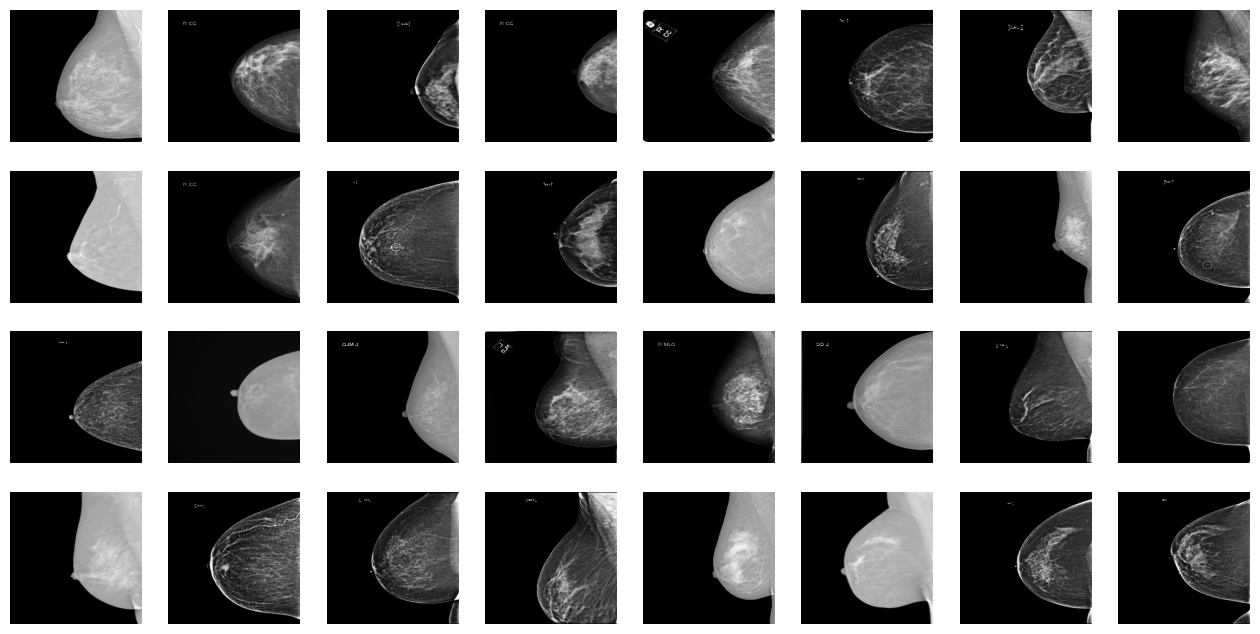

In [ ]:
import matplotlib.pyplot as plt
import torch

# Function to unnormalize image
def unnormalize(tensor, mean, std):
    """
    Unnormalize the tensor to the range [0, 1].
    """
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    return tensor * std + mean

# Visualizing one batch of images
def visualize_batch(dataloader):
    # Get one batch from the dataloader
    batch = next(iter(dataloader))  # Get one batch

    # Handle different dataloader formats (with/without labels)
    if isinstance(batch, (list, tuple)):
        images = batch[0]  # Extract images if labels exist
    else:
        images = batch  # If there are no labels, the batch is just images

    # Unnormalize the images (since you used Normalize([0.5], [0.5]))
    images = unnormalize(images, mean=[0.5], std=[0.5])

    # Plot the images in the batch
    batch_size = images.size(0)
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))  # Adjust grid size to display 32 images (4x8 grid)

    for i in range(min(batch_size, 32)):  # Limit to 32 images for display
        ax = axes[i // 8, i % 8]  # Find the correct subplot position
        ax.imshow(images[i].squeeze(), cmap='gray')  # Remove the channel dimension and display as grayscale
        ax.axis('off')  # Hide axes

    plt.show()

# Call function to visualize batch (make sure 'dataloader' is defined)
visualize_batch(dataloader)

In [ ]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch

def generate_and_display_images(generator, num_images=25, latent_dim=100, nrow=5, device="cuda"):
    """
    Generate and display images using the trained generator.

    Args:
        generator (nn.Module): The trained generator model.
        num_images (int): Number of images to generate.
        latent_dim (int): Dimensionality of the latent space.
        nrow (int): Number of images per row in the grid.
        device (str): Device to perform computations on ("cuda" or "cpu").
    """
    generator.eval()  # Set generator to evaluation mode
    with torch.no_grad():  # No need to compute gradients
        # Generate latent vectors
        z = torch.randn(num_images, latent_dim).to(device)
        # Generate images
        generated_images = generator(z)

        # Debug: Print shape of generated images
        print("Generated images shape:", generated_images.shape)

        # Remove any extra dimensions if necessary
        if generated_images.dim() == 5:  # Check if there's an extra dimension
            generated_images = generated_images.squeeze(2)

        # Normalize and move to CPU for display
        generated_images = generated_images.cpu()

        # Display images using a grid
        grid = make_grid(generated_images, nrow=nrow, normalize=True)
        plt.figure(figsize=(10, 10))
        plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
        plt.axis("off")
        plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Generated images shape: torch.Size([7, 1, 256, 256])


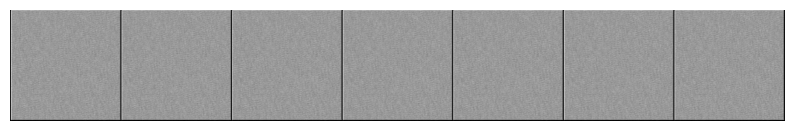

[Epoch 1/150] [D loss: -173.85391235351562] [G loss: 875.4235229492188]
[Epoch 2/150] [D loss: -36.852928161621094] [G loss: 250.1712646484375]
[Epoch 3/150] [D loss: -56.53109359741211] [G loss: 10.113282203674316]
[Epoch 4/150] [D loss: -53.199214935302734] [G loss: -49.03485107421875]
[Epoch 5/150] [D loss: -49.81340408325195] [G loss: -64.92422485351562]
Generated images shape: torch.Size([7, 1, 256, 256])


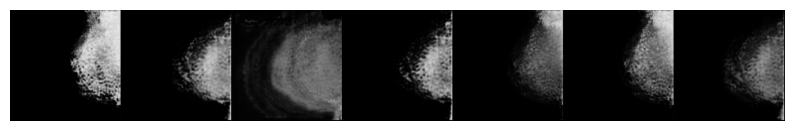

[Epoch 6/150] [D loss: 58.97162628173828] [G loss: 54.84351348876953]
[Epoch 7/150] [D loss: -25.690296173095703] [G loss: 9.522211074829102]
[Epoch 8/150] [D loss: -54.434913635253906] [G loss: -2.675493001937866]
[Epoch 9/150] [D loss: -12.999841690063477] [G loss: -120.5295639038086]
[Epoch 10/150] [D loss: -53.63694763183594] [G loss: 9.77018928527832]
Saved images for 10th epoch at: /content/drive/My Drive/GAN_Generated_Images/10th_epoch
Checkpoint saved at epoch 10 to Google Drive:
/content/drive/My Drive/GAN_Weights/generator_epoch_10.pth
/content/drive/My Drive/GAN_Weights/discriminator_epoch_10.pth
Generated images shape: torch.Size([7, 1, 256, 256])


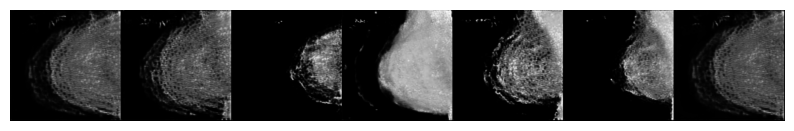

[Epoch 11/150] [D loss: -68.78974151611328] [G loss: -32.822628021240234]
[Epoch 12/150] [D loss: 11.22269344329834] [G loss: -87.71342468261719]
[Epoch 13/150] [D loss: -70.73968505859375] [G loss: -6.496814727783203]
[Epoch 14/150] [D loss: -26.90011215209961] [G loss: 159.34109497070312]
[Epoch 15/150] [D loss: -99.97244262695312] [G loss: 41.639434814453125]
Generated images shape: torch.Size([7, 1, 256, 256])


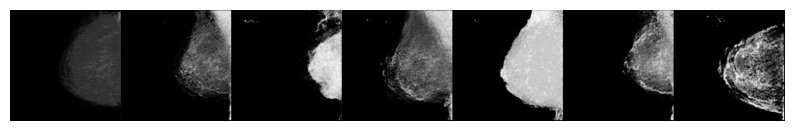

[Epoch 16/150] [D loss: -53.41209411621094] [G loss: -28.89837646484375]
[Epoch 17/150] [D loss: -33.65854263305664] [G loss: 23.5726261138916]
[Epoch 18/150] [D loss: -39.907161712646484] [G loss: 12.524798393249512]
[Epoch 19/150] [D loss: -14.865023612976074] [G loss: -43.830318450927734]
[Epoch 20/150] [D loss: -25.401065826416016] [G loss: -62.43552017211914]
Saved images for 20th epoch at: /content/drive/My Drive/GAN_Generated_Images/20th_epoch
Checkpoint saved at epoch 20 to Google Drive:
/content/drive/My Drive/GAN_Weights/generator_epoch_20.pth
/content/drive/My Drive/GAN_Weights/discriminator_epoch_20.pth
Generated images shape: torch.Size([7, 1, 256, 256])


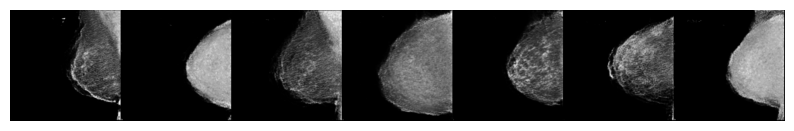

[Epoch 21/150] [D loss: 6.293752670288086] [G loss: -69.93797302246094]
[Epoch 22/150] [D loss: -36.76576614379883] [G loss: -53.17844009399414]
[Epoch 23/150] [D loss: -24.897911071777344] [G loss: -31.460371017456055]
[Epoch 24/150] [D loss: -30.74311065673828] [G loss: -26.889842987060547]
[Epoch 25/150] [D loss: -53.731056213378906] [G loss: -8.231947898864746]
Generated images shape: torch.Size([7, 1, 256, 256])


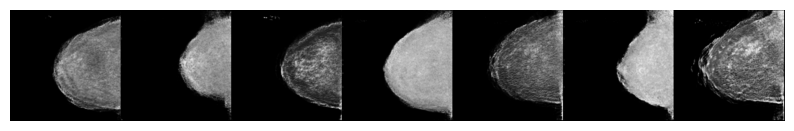

[Epoch 26/150] [D loss: -45.094398498535156] [G loss: -71.4441909790039]
[Epoch 27/150] [D loss: -23.138626098632812] [G loss: 10.095220565795898]
[Epoch 28/150] [D loss: -13.475712776184082] [G loss: 31.34178924560547]
[Epoch 29/150] [D loss: -73.17337036132812] [G loss: 13.344456672668457]
[Epoch 30/150] [D loss: -70.1956787109375] [G loss: -28.934431076049805]
Saved images for 30th epoch at: /content/drive/My Drive/GAN_Generated_Images/30th_epoch
Checkpoint saved at epoch 30 to Google Drive:
/content/drive/My Drive/GAN_Weights/generator_epoch_30.pth
/content/drive/My Drive/GAN_Weights/discriminator_epoch_30.pth
Generated images shape: torch.Size([7, 1, 256, 256])


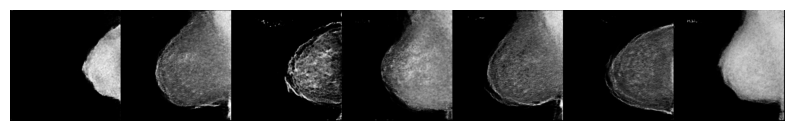

[Epoch 31/150] [D loss: -49.277610778808594] [G loss: -14.172425270080566]
[Epoch 32/150] [D loss: -60.775997161865234] [G loss: -79.41085052490234]
[Epoch 33/150] [D loss: -27.084693908691406] [G loss: -70.47935485839844]
[Epoch 34/150] [D loss: -37.41008758544922] [G loss: 18.279075622558594]
[Epoch 35/150] [D loss: -46.50994110107422] [G loss: -37.29864501953125]
Generated images shape: torch.Size([7, 1, 256, 256])


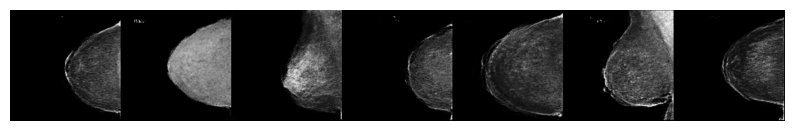

[Epoch 36/150] [D loss: -26.880199432373047] [G loss: -88.47201538085938]
[Epoch 37/150] [D loss: -45.783199310302734] [G loss: -27.911375045776367]
[Epoch 38/150] [D loss: 26.59157943725586] [G loss: 24.54851531982422]
[Epoch 39/150] [D loss: -35.200016021728516] [G loss: -88.87840270996094]
[Epoch 40/150] [D loss: -50.95101547241211] [G loss: -44.20682907104492]
Saved images for 40th epoch at: /content/drive/My Drive/GAN_Generated_Images/40th_epoch
Checkpoint saved at epoch 40 to Google Drive:
/content/drive/My Drive/GAN_Weights/generator_epoch_40.pth
/content/drive/My Drive/GAN_Weights/discriminator_epoch_40.pth
Generated images shape: torch.Size([7, 1, 256, 256])


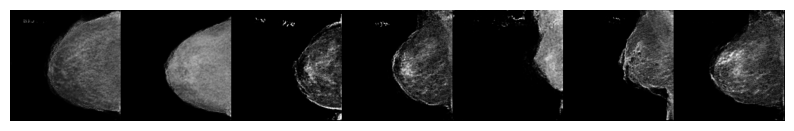

[Epoch 41/150] [D loss: 6.069149971008301] [G loss: -11.011290550231934]
[Epoch 42/150] [D loss: -27.00604820251465] [G loss: -47.44673156738281]
[Epoch 43/150] [D loss: 36.77001190185547] [G loss: 196.10989379882812]
[Epoch 44/150] [D loss: -20.73271369934082] [G loss: -39.797645568847656]
[Epoch 45/150] [D loss: -29.215435028076172] [G loss: -21.93559455871582]
Generated images shape: torch.Size([7, 1, 256, 256])


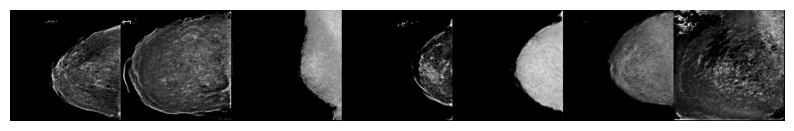

[Epoch 46/150] [D loss: -2.1285362243652344] [G loss: 83.11717987060547]
[Epoch 47/150] [D loss: -34.714073181152344] [G loss: -22.750205993652344]
[Epoch 48/150] [D loss: -52.516510009765625] [G loss: 24.540390014648438]
[Epoch 49/150] [D loss: -28.119972229003906] [G loss: 1.928505539894104]
[Epoch 50/150] [D loss: -27.951156616210938] [G loss: -9.895386695861816]
Saved images for 50th epoch at: /content/drive/My Drive/GAN_Generated_Images/50th_epoch
Checkpoint saved at epoch 50 to Google Drive:
/content/drive/My Drive/GAN_Weights/generator_epoch_50.pth
/content/drive/My Drive/GAN_Weights/discriminator_epoch_50.pth
Generated images shape: torch.Size([7, 1, 256, 256])


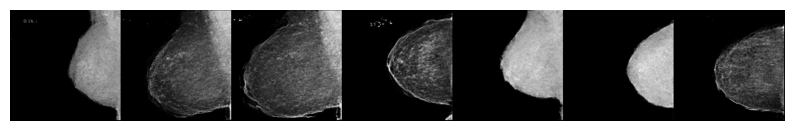

[Epoch 51/150] [D loss: -29.687145233154297] [G loss: -9.715970993041992]
[Epoch 52/150] [D loss: -35.256134033203125] [G loss: -50.570709228515625]
[Epoch 53/150] [D loss: -44.4312858581543] [G loss: 81.111328125]
[Epoch 54/150] [D loss: -59.00213623046875] [G loss: -46.39167022705078]
[Epoch 55/150] [D loss: -55.918190002441406] [G loss: 33.330322265625]
Generated images shape: torch.Size([7, 1, 256, 256])


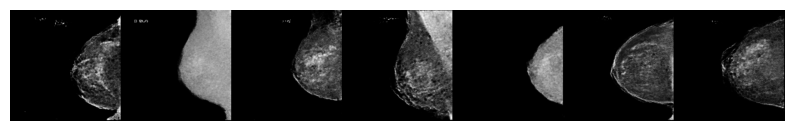

[Epoch 56/150] [D loss: -4.178288459777832] [G loss: -0.6753451824188232]
[Epoch 57/150] [D loss: -3.053738594055176] [G loss: -41.61476135253906]
[Epoch 58/150] [D loss: -47.30865478515625] [G loss: -58.16464614868164]
[Epoch 59/150] [D loss: -2.718160629272461] [G loss: 39.067161560058594]
[Epoch 60/150] [D loss: -31.17549705505371] [G loss: 1.4981837272644043]
Saved images for 60th epoch at: /content/drive/My Drive/GAN_Generated_Images/60th_epoch
Checkpoint saved at epoch 60 to Google Drive:
/content/drive/My Drive/GAN_Weights/generator_epoch_60.pth
/content/drive/My Drive/GAN_Weights/discriminator_epoch_60.pth
Generated images shape: torch.Size([7, 1, 256, 256])


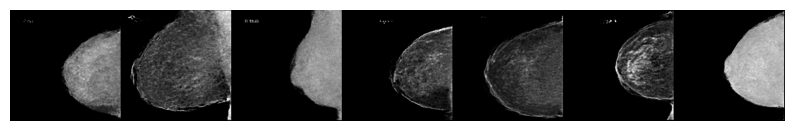

[Epoch 61/150] [D loss: -35.189666748046875] [G loss: -32.133209228515625]
[Epoch 62/150] [D loss: -38.86119079589844] [G loss: -6.0594258308410645]
[Epoch 63/150] [D loss: -60.422698974609375] [G loss: -28.420612335205078]
[Epoch 64/150] [D loss: -27.147764205932617] [G loss: -29.173431396484375]
[Epoch 65/150] [D loss: -35.50467300415039] [G loss: 6.5022196769714355]
Generated images shape: torch.Size([7, 1, 256, 256])


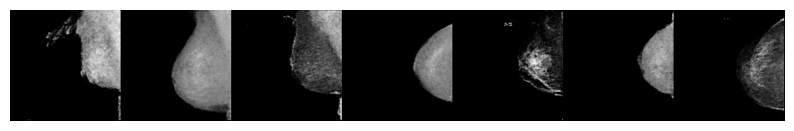

[Epoch 66/150] [D loss: -21.906702041625977] [G loss: -7.646622657775879]
[Epoch 67/150] [D loss: -24.972185134887695] [G loss: -15.337060928344727]
[Epoch 68/150] [D loss: 59.38996124267578] [G loss: 149.4048614501953]
[Epoch 69/150] [D loss: -12.334724426269531] [G loss: -54.55154037475586]


In [ ]:
import torch
from torch.autograd import Variable
import numpy as np
import os
from torchvision.utils import save_image

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define directories inside Google Drive
base_image_dir = "/content/drive/My Drive/GAN_Generated_Images"
save_dir = "/content/drive/My Drive/GAN_Weights"
os.makedirs(base_image_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)

checkpoint_interval = 10  # Save images every 10 epochs

# Set the device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image shape and model setup
img_shape = (1, img_size, img_size)

# Instantiate models and move them to the GPU
generator = Generator(latent_dim=latent_dim, img_shape=img_shape).to(device)
discriminator = Discriminator(img_shape=img_shape).to(device)

# Define optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(b1, b2))

# Learning Rate Scheduler
scheduler_G = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_G, T_max=n_epochs)
scheduler_D = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D, T_max=n_epochs)

# Gradient penalty function
def compute_gradient_penalty(D, real_samples, fake_samples):
    alpha = torch.tensor(np.random.random((real_samples.size(0), 1, 1, 1)), dtype=torch.float32, device=device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = D(interpolates)
    fake = Variable(torch.ones(real_samples.shape[0], 1, dtype=torch.float32, device=device), requires_grad=False)
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

# ----------
#  Training
# ----------
batches_done = 0
d_loss_val = 0
g_loss_val = 0

for epoch in range(1, n_epochs + 1):
    if epoch % 5 == 1:
        generate_and_display_images(generator, num_images=7, latent_dim=latent_dim, nrow=7, device=device)

    for i, imgs in enumerate(dataloader):
        real_imgs = Variable(imgs.type(torch.float32).to(device))

        # Train Discriminator
        optimizer_D.zero_grad()
        z = Variable(torch.tensor(np.random.normal(0, 1, (imgs.shape[0], latent_dim)), dtype=torch.float32).to(device))
        fake_imgs = generator(z).view(imgs.shape[0], 1, img_size, img_size)
        real_validity = discriminator(real_imgs)
        fake_validity = discriminator(fake_imgs)
        gradient_penalty = compute_gradient_penalty(discriminator, real_imgs.data, fake_imgs.data)
        d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + lambda_gp * gradient_penalty
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
        d_loss.backward()
        d_loss_val = d_loss.item()
        optimizer_D.step()

        optimizer_G.zero_grad()

        # Train the Generator every n_critic steps
        if i % n_critic == 0:
            fake_imgs = generator(z).view(imgs.shape[0], 1, img_size, img_size)
            fake_validity = discriminator(fake_imgs)
            g_loss = -torch.mean(fake_validity)
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
            g_loss.backward()
            optimizer_G.step()
            g_loss_val = g_loss.item()
            if batches_done % sample_interval == 0:
                save_image(fake_imgs.data[:25], "images/%d.png" % batches_done, nrow=5, normalize=True)
            batches_done += 1

        # Step the schedulers (learning rate adjustment)
        scheduler_G.step()
        scheduler_D.step()

    print(f"[Epoch {epoch}/{n_epochs}] [D loss: {d_loss_val}] [G loss: {g_loss_val}]")

    # ----------------------------
    #  Save Images Every 10 Epochs
    # ----------------------------
    if epoch % checkpoint_interval == 0:
        epoch_folder = os.path.join(base_image_dir, f"{epoch}th_epoch")
        os.makedirs(epoch_folder, exist_ok=True)  # Create folder for epoch

        num_samples = 25  # Number of images to save per epoch
        z = torch.randn(num_samples, latent_dim, device=device)
        generated_images = generator(z).view(num_samples, 1, img_size, img_size)

        for j in range(num_samples):
            image_path = os.path.join(epoch_folder, f"image_{j+1}.png")
            save_image(generated_images[j], image_path, normalize=True)

        print(f"Saved images for {epoch}th epoch at: {epoch_folder}")

    # Save model checkpoint, optimizer, and scheduler states every 10 epochs
    if epoch % 10 == 0:
        generator_path = os.path.join(save_dir, f"generator_epoch_{epoch}.pth")
        discriminator_path = os.path.join(save_dir, f"discriminator_epoch_{epoch}.pth")
        optimizer_G_path = os.path.join(save_dir, f"optimizer_G_epoch_{epoch}.pth")
        optimizer_D_path = os.path.join(save_dir, f"optimizer_D_epoch_{epoch}.pth")
        scheduler_G_path = os.path.join(save_dir, f"scheduler_G_epoch_{epoch}.pth")
        scheduler_D_path = os.path.join(save_dir, f"scheduler_D_epoch_{epoch}.pth")

        # Save model state dictionaries
        torch.save(generator.state_dict(), generator_path)
        torch.save(discriminator.state_dict(), discriminator_path)

        # Save optimizer state dictionaries
        torch.save(optimizer_G.state_dict(), optimizer_G_path)
        torch.save(optimizer_D.state_dict(), optimizer_D_path)

        # Save scheduler state dictionaries
        torch.save(scheduler_G.state_dict(), scheduler_G_path)
        torch.save(scheduler_D.state_dict(), scheduler_D_path)

        print(f"Checkpoint saved at epoch {epoch} to Google Drive:\n{generator_path}\n{discriminator_path}")

# -----------------------
#  Save Final Model to Drive
# -----------------------
generator_path = os.path.join(save_dir, "generator_final.pth")
discriminator_path = os.path.join(save_dir, "discriminator_final.pth")
optimizer_G_path = os.path.join(save_dir, "optimizer_G_final.pth")
optimizer_D_path = os.path.join(save_dir, "optimizer_D_final.pth")
scheduler_G_path = os.path.join(save_dir, "scheduler_G_final.pth")
scheduler_D_path = os.path.join(save_dir, "scheduler_D_final.pth")

# Save final model weights
torch.save(generator.state_dict(), generator_path)

# Save final optimizer and scheduler states
torch.save(optimizer_G.state_dict(), optimizer_G_path)
torch.save(optimizer_D.state_dict(), optimizer_D_path)
torch.save(scheduler_G.state_dict(), scheduler_G_path)
torch.save(scheduler_D.state_dict(), scheduler_D_path)

print(f"Final model saved to Google Drive at:\n{generator_path}\n{discriminator_path}")

# ----------------------------
#  Generate and Save 1000 Images to Drive
# ----------------------------
num_samples = 1000  # Number of final images to save
z = torch.randn(num_samples, latent_dim, device=device)  # Generate latent vectors
final_images = generator(z).view(num_samples, 1, img_size, img_size)  # Reshape output

for i in range(num_samples):
    save_path = os.path.join(base_image_dir, f"generated_image_{i+1}.png")
    save_image(final_images[i], save_path, normalize=True)

print(f"Final generated images saved to Google Drive at: {base_image_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-19-6811dda4c36f>:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load(generator_path, map_location=device))
<ipython-input-1

Loaded checkpoint from epoch 90. Resuming training...
Generated images shape: torch.Size([7, 1, 256, 256])


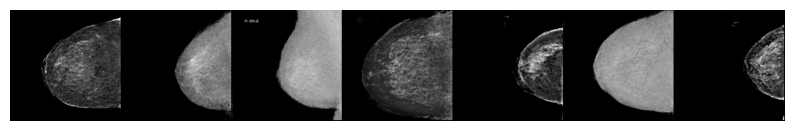

[Epoch 91/150] [D loss: 1.6336560249328613] [G loss: 0.5751466751098633]
[Epoch 92/150] [D loss: -42.773014068603516] [G loss: 69.66697692871094]
[Epoch 93/150] [D loss: -16.885379791259766] [G loss: -0.5673449039459229]
[Epoch 94/150] [D loss: -49.312782287597656] [G loss: 49.73896408081055]
[Epoch 95/150] [D loss: -24.471023559570312] [G loss: -36.028289794921875]
Generated images shape: torch.Size([7, 1, 256, 256])


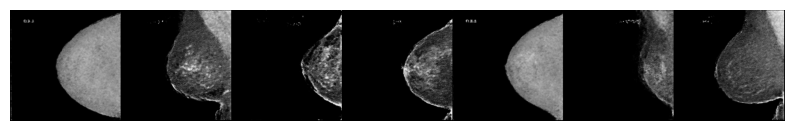

[Epoch 96/150] [D loss: -35.473670959472656] [G loss: -36.770240783691406]
[Epoch 97/150] [D loss: -18.821048736572266] [G loss: 7.286751747131348]
[Epoch 98/150] [D loss: -18.365215301513672] [G loss: 6.774604320526123]
[Epoch 99/150] [D loss: -16.99831199645996] [G loss: -10.634747505187988]
[Epoch 100/150] [D loss: -22.04873275756836] [G loss: -3.4466190338134766]
Saved images for 100th epoch at: /content/drive/My Drive/GAN_Generated_Images/100th_epoch
Checkpoint saved at epoch 100 to Google Drive:
/content/drive/My Drive/GAN_Weights/generator_epoch_100.pth
/content/drive/My Drive/GAN_Weights/discriminator_epoch_100.pth
Generated images shape: torch.Size([7, 1, 256, 256])


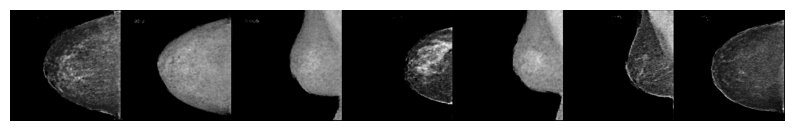

[Epoch 101/150] [D loss: -2.6261343955993652] [G loss: 92.23419189453125]
[Epoch 102/150] [D loss: 19.26246452331543] [G loss: -38.0894775390625]
[Epoch 103/150] [D loss: -23.553958892822266] [G loss: -16.80166244506836]
[Epoch 104/150] [D loss: -28.272388458251953] [G loss: 6.477431774139404]
[Epoch 105/150] [D loss: -13.16629695892334] [G loss: 5.301650047302246]
Generated images shape: torch.Size([7, 1, 256, 256])


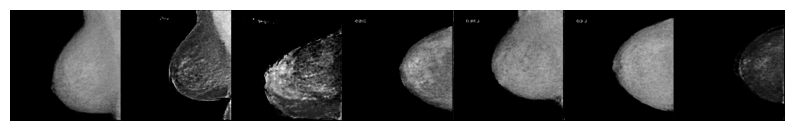

[Epoch 106/150] [D loss: 24.19411849975586] [G loss: -32.26553726196289]
[Epoch 107/150] [D loss: -56.92231369018555] [G loss: -69.18902587890625]
[Epoch 108/150] [D loss: -80.49394226074219] [G loss: 33.17660140991211]
[Epoch 109/150] [D loss: -26.738136291503906] [G loss: 10.923069953918457]
[Epoch 110/150] [D loss: 5.7471137046813965] [G loss: -38.17969512939453]
Saved images for 110th epoch at: /content/drive/My Drive/GAN_Generated_Images/110th_epoch
Checkpoint saved at epoch 110 to Google Drive:
/content/drive/My Drive/GAN_Weights/generator_epoch_110.pth
/content/drive/My Drive/GAN_Weights/discriminator_epoch_110.pth
Generated images shape: torch.Size([7, 1, 256, 256])


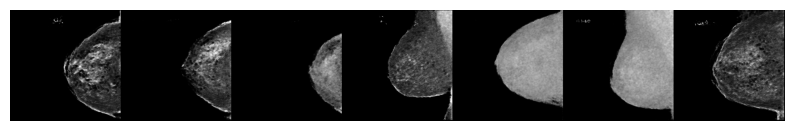

[Epoch 111/150] [D loss: -32.09831619262695] [G loss: 23.62992286682129]
[Epoch 112/150] [D loss: 16.606216430664062] [G loss: -51.00521469116211]
[Epoch 113/150] [D loss: 5.696231842041016] [G loss: 30.971521377563477]
[Epoch 114/150] [D loss: -25.125200271606445] [G loss: 18.45755386352539]
[Epoch 115/150] [D loss: -18.222089767456055] [G loss: 11.87924861907959]
Generated images shape: torch.Size([7, 1, 256, 256])


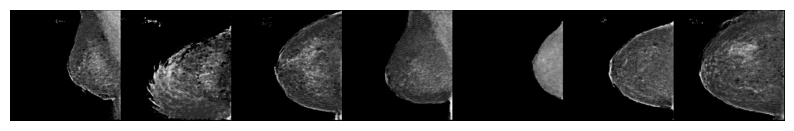

[Epoch 116/150] [D loss: -30.86672019958496] [G loss: -12.599076271057129]
[Epoch 117/150] [D loss: -32.56711959838867] [G loss: -23.083667755126953]
[Epoch 118/150] [D loss: -18.471080780029297] [G loss: 13.372708320617676]
[Epoch 119/150] [D loss: -35.92625045776367] [G loss: 3.9464447498321533]
[Epoch 120/150] [D loss: -12.595697402954102] [G loss: -13.579544067382812]
Saved images for 120th epoch at: /content/drive/My Drive/GAN_Generated_Images/120th_epoch
Checkpoint saved at epoch 120 to Google Drive:
/content/drive/My Drive/GAN_Weights/generator_epoch_120.pth
/content/drive/My Drive/GAN_Weights/discriminator_epoch_120.pth
Generated images shape: torch.Size([7, 1, 256, 256])


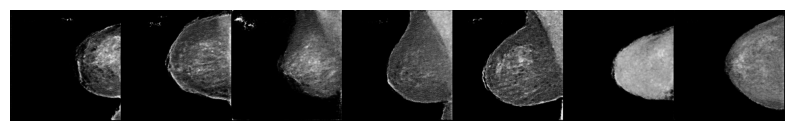

[Epoch 121/150] [D loss: -2.605503559112549] [G loss: -11.609058380126953]
[Epoch 122/150] [D loss: -12.513498306274414] [G loss: -1.1006109714508057]
[Epoch 123/150] [D loss: -12.294618606567383] [G loss: 0.9878442287445068]
[Epoch 124/150] [D loss: 5.794722557067871] [G loss: 29.809650421142578]
[Epoch 125/150] [D loss: -42.16088104248047] [G loss: 14.028135299682617]
Generated images shape: torch.Size([7, 1, 256, 256])


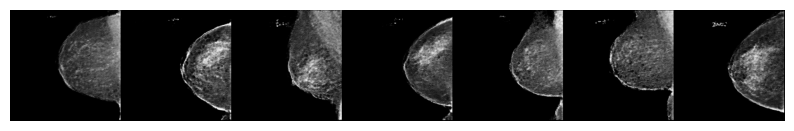

[Epoch 126/150] [D loss: 18.91101837158203] [G loss: -23.535633087158203]
[Epoch 127/150] [D loss: -29.39023208618164] [G loss: -2.772113800048828]
[Epoch 128/150] [D loss: -28.413326263427734] [G loss: 72.49076843261719]
[Epoch 129/150] [D loss: -17.77005958557129] [G loss: 6.294981956481934]
[Epoch 130/150] [D loss: -26.081382751464844] [G loss: -24.564085006713867]
Saved images for 130th epoch at: /content/drive/My Drive/GAN_Generated_Images/130th_epoch
Checkpoint saved at epoch 130 to Google Drive:
/content/drive/My Drive/GAN_Weights/generator_epoch_130.pth
/content/drive/My Drive/GAN_Weights/discriminator_epoch_130.pth
Generated images shape: torch.Size([7, 1, 256, 256])


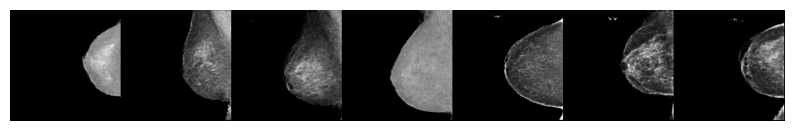

[Epoch 131/150] [D loss: -27.60515594482422] [G loss: 11.444101333618164]
[Epoch 132/150] [D loss: -26.693893432617188] [G loss: -15.271222114562988]
[Epoch 133/150] [D loss: -27.45572853088379] [G loss: 17.242504119873047]
[Epoch 134/150] [D loss: -17.395063400268555] [G loss: -5.71541690826416]
[Epoch 135/150] [D loss: -34.636566162109375] [G loss: 4.196063995361328]
Generated images shape: torch.Size([7, 1, 256, 256])


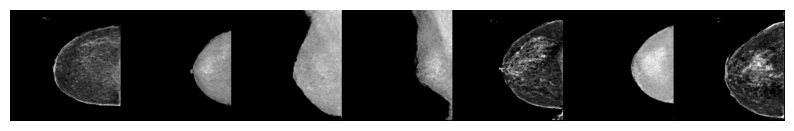

[Epoch 136/150] [D loss: -17.572311401367188] [G loss: 26.542133331298828]
[Epoch 137/150] [D loss: -3.5641298294067383] [G loss: -9.123239517211914]
[Epoch 138/150] [D loss: 7.911487102508545] [G loss: -6.682778358459473]
[Epoch 139/150] [D loss: -41.833351135253906] [G loss: 36.3942756652832]
[Epoch 140/150] [D loss: -22.46433448791504] [G loss: 13.88412857055664]
Saved images for 140th epoch at: /content/drive/My Drive/GAN_Generated_Images/140th_epoch
Checkpoint saved at epoch 140 to Google Drive:
/content/drive/My Drive/GAN_Weights/generator_epoch_140.pth
/content/drive/My Drive/GAN_Weights/discriminator_epoch_140.pth
Generated images shape: torch.Size([7, 1, 256, 256])


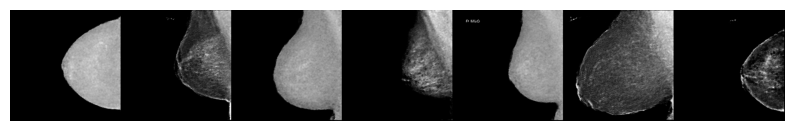

[Epoch 141/150] [D loss: -3.418084144592285] [G loss: -43.16917419433594]
[Epoch 142/150] [D loss: -34.91968536376953] [G loss: 14.276042938232422]
[Epoch 143/150] [D loss: -20.808609008789062] [G loss: -15.836867332458496]
[Epoch 144/150] [D loss: -38.4446907043457] [G loss: 45.086631774902344]
[Epoch 145/150] [D loss: -30.266042709350586] [G loss: 6.173661708831787]
Generated images shape: torch.Size([7, 1, 256, 256])


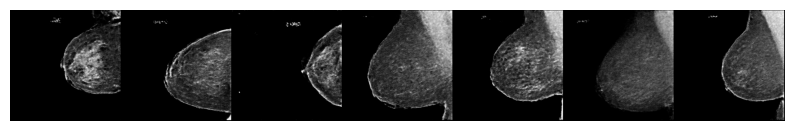

[Epoch 146/150] [D loss: -18.893022537231445] [G loss: 3.338435173034668]
[Epoch 147/150] [D loss: 2.4255523681640625] [G loss: 32.98517608642578]
[Epoch 148/150] [D loss: -55.92444610595703] [G loss: -8.937467575073242]
[Epoch 148/150] [D loss: -55.92444610595703] [G loss: -8.937467575073242]
[Epoch 149/150] [D loss: -39.906471252441406] [G loss: -40.543392181396484]
[Epoch 149/150] [D loss: -39.906471252441406] [G loss: -40.543392181396484]
[Epoch 150/150] [D loss: -30.153045654296875] [G loss: -3.676365375518799]
[Epoch 150/150] [D loss: -30.153045654296875] [G loss: -3.676365375518799]
Saved images for 150th epoch at: /content/drive/My Drive/GAN_Generated_Images/150th_epoch
Saved images for 150th epoch at: /content/drive/My Drive/GAN_Generated_Images/150th_epoch
Checkpoint saved at epoch 150 to Google Drive:
/content/drive/My Drive/GAN_Weights/generator_epoch_150.pth
/content/drive/My Drive/GAN_Weights/discriminator_epoch_150.pth
Checkpoint saved at epoch 150 to Google Drive:
/cont

In [19]:
import torch
from torch.autograd import Variable
import numpy as np
import os
from torchvision.utils import save_image

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define directories
base_image_dir = "/content/drive/My Drive/GAN_Generated_Images"
save_dir = "/content/drive/My Drive/GAN_Weights"
os.makedirs(base_image_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)

checkpoint_interval = 10  # Save images every 10 epochs

# Gradient penalty function
def compute_gradient_penalty(D, real_samples, fake_samples):
    alpha = torch.tensor(np.random.random((real_samples.size(0), 1, 1, 1)), dtype=torch.float32, device=device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = D(interpolates)
    fake = Variable(torch.ones(real_samples.shape[0], 1, dtype=torch.float32, device=device), requires_grad=False)
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image shape
img_shape = (1, img_size, img_size)

# Instantiate models
generator = Generator(latent_dim=latent_dim, img_shape=img_shape).to(device)
discriminator = Discriminator(img_shape=img_shape).to(device)

# Define optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(b1, b2))

# Learning rate scheduler
scheduler_G = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_G, T_max=n_epochs)
scheduler_D = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D, T_max=n_epochs)

# -------- Load Checkpoints (Resume Training) -------- #
resume_epoch = 90  # Change this to the last completed epoch

generator_path = os.path.join(save_dir, f"generator_epoch_{resume_epoch}.pth")
discriminator_path = os.path.join(save_dir, f"discriminator_epoch_{resume_epoch}.pth")
optimizer_G_path = os.path.join(save_dir, f"optimizer_G_epoch_{resume_epoch}.pth")
optimizer_D_path = os.path.join(save_dir, f"optimizer_D_epoch_{resume_epoch}.pth")
scheduler_G_path = os.path.join(save_dir, f"scheduler_G_epoch_{resume_epoch}.pth")
scheduler_D_path = os.path.join(save_dir, f"scheduler_D_epoch_{resume_epoch}.pth")

if os.path.exists(generator_path) and os.path.exists(discriminator_path):
    generator.load_state_dict(torch.load(generator_path, map_location=device))
    discriminator.load_state_dict(torch.load(discriminator_path, map_location=device))
    optimizer_G.load_state_dict(torch.load(optimizer_G_path, map_location=device))
    optimizer_D.load_state_dict(torch.load(optimizer_D_path, map_location=device))
    scheduler_G.load_state_dict(torch.load(scheduler_G_path, map_location=device))
    scheduler_D.load_state_dict(torch.load(scheduler_D_path, map_location=device))
    print(f"Loaded checkpoint from epoch {resume_epoch}. Resuming training...")

# ----------
#  Resume Training
# ----------
batches_done = 0
d_loss_val = 0
g_loss_val = 0

for epoch in range(resume_epoch + 1, n_epochs + 1):
    if epoch % 5 == 1:
        generate_and_display_images(generator, num_images=7, latent_dim=latent_dim, nrow=7, device=device)

    for i, imgs in enumerate(dataloader):
        real_imgs = Variable(imgs.type(torch.float32).to(device))

        # Train Discriminator
        optimizer_D.zero_grad()
        z = Variable(torch.tensor(np.random.normal(0, 1, (imgs.shape[0], latent_dim)), dtype=torch.float32).to(device))
        fake_imgs = generator(z).view(imgs.shape[0], 1, img_size, img_size)
        real_validity = discriminator(real_imgs)
        fake_validity = discriminator(fake_imgs)
        gradient_penalty = compute_gradient_penalty(discriminator, real_imgs.data, fake_imgs.data)
        d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + lambda_gp * gradient_penalty
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
        d_loss.backward()
        d_loss_val = d_loss.item()
        optimizer_D.step()

        optimizer_G.zero_grad()

        # Train the Generator every n_critic steps
        if i % n_critic == 0:
            fake_imgs = generator(z).view(imgs.shape[0], 1, img_size, img_size)
            fake_validity = discriminator(fake_imgs)
            g_loss = -torch.mean(fake_validity)
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
            g_loss.backward()
            optimizer_G.step()
            g_loss_val = g_loss.item()
            if batches_done % sample_interval == 0:
                save_image(fake_imgs.data[:25], "images/%d.png" % batches_done, nrow=5, normalize=True)
            batches_done += 1

        # Step the schedulers (learning rate adjustment)
        scheduler_G.step()
        scheduler_D.step()

    print(f"[Epoch {epoch}/{n_epochs}] [D loss: {d_loss_val}] [G loss: {g_loss_val}]")

    # ----------------------------
    #  Save Images Every 10 Epochs
    # ----------------------------
    if epoch % checkpoint_interval == 0:
        epoch_folder = os.path.join(base_image_dir, f"{epoch}th_epoch")
        os.makedirs(epoch_folder, exist_ok=True)

        num_samples = 25
        z = torch.randn(num_samples, latent_dim, device=device)
        generated_images = generator(z).view(num_samples, 1, img_size, img_size)

        for j in range(num_samples):
            image_path = os.path.join(epoch_folder, f"image_{j+1}.png")
            save_image(generated_images[j], image_path, normalize=True)

        print(f"Saved images for {epoch}th epoch at: {epoch_folder}")

    # Save model checkpoint, optimizer, and scheduler states every 10 epochs
    if epoch % 10 == 0:
        generator_path = os.path.join(save_dir, f"generator_epoch_{epoch}.pth")
        discriminator_path = os.path.join(save_dir, f"discriminator_epoch_{epoch}.pth")
        optimizer_G_path = os.path.join(save_dir, f"optimizer_G_epoch_{epoch}.pth")
        optimizer_D_path = os.path.join(save_dir, f"optimizer_D_epoch_{epoch}.pth")
        scheduler_G_path = os.path.join(save_dir, f"scheduler_G_epoch_{epoch}.pth")
        scheduler_D_path = os.path.join(save_dir, f"scheduler_D_epoch_{epoch}.pth")

        torch.save(generator.state_dict(), generator_path)
        torch.save(discriminator.state_dict(), discriminator_path)
        torch.save(optimizer_G.state_dict(), optimizer_G_path)
        torch.save(optimizer_D.state_dict(), optimizer_D_path)
        torch.save(scheduler_G.state_dict(), scheduler_G_path)
        torch.save(scheduler_D.state_dict(), scheduler_D_path)

        print(f"Checkpoint saved at epoch {epoch} to Google Drive:\n{generator_path}\n{discriminator_path}")

# -----------------------
#  Save Final Model to Drive
# -----------------------
generator_path = os.path.join(save_dir, "generator_final.pth")
discriminator_path = os.path.join(save_dir, "discriminator_final.pth")
optimizer_G_path = os.path.join(save_dir, "optimizer_G_final.pth")
optimizer_D_path = os.path.join(save_dir, "optimizer_D_final.pth")
scheduler_G_path = os.path.join(save_dir, "scheduler_G_final.pth")
scheduler_D_path = os.path.join(save_dir, "scheduler_D_final.pth")

torch.save(generator.state_dict(), generator_path)
torch.save(discriminator.state_dict(), discriminator_path)
torch.save(optimizer_G.state_dict(), optimizer_G_path)
torch.save(optimizer_D.state_dict(), optimizer_D_path)
torch.save(scheduler_G.state_dict(), scheduler_G_path)
torch.save(scheduler_D.state_dict(), scheduler_D_path)

print(f"Final model saved to Google Drive at:\n{generator_path}\n{discriminator_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-20-d21f776491aa>:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load(generator_path, map_location=device))
<ipython-input-2

Loaded checkpoint from epoch 150. Resuming training...
Generated images shape: torch.Size([7, 1, 256, 256])


<ipython-input-20-d21f776491aa>:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  scheduler_G.load_state_dict(torch.load(scheduler_G_path, map_location=device))
<ipython-inp

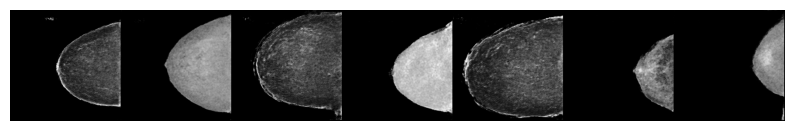

[Epoch 151/155] [D loss: -0.8903241157531738] [G loss: 11.607072830200195]
[Epoch 152/155] [D loss: 2.656195640563965] [G loss: 57.131813049316406]
[Epoch 153/155] [D loss: -45.55376434326172] [G loss: -10.906875610351562]
[Epoch 154/155] [D loss: -17.35024070739746] [G loss: 18.90670394897461]
[Epoch 155/155] [D loss: 3.5455400943756104] [G loss: -32.08199691772461]
Generating 2000 final images...
All 2000 images saved to: /content/drive/My Drive/GAN_Generated_Images/Final_Generated_Images
Final model saved to Google Drive at:
/content/drive/My Drive/GAN_Weights/generator_final.pth
/content/drive/My Drive/GAN_Weights/discriminator_final.pth


In [20]:
import torch
from torch.autograd import Variable
import numpy as np
import os
from torchvision.utils import save_image

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define directories
base_image_dir = "/content/drive/My Drive/GAN_Generated_Images"
save_dir = "/content/drive/My Drive/GAN_Weights"
final_image_dir = os.path.join(base_image_dir, "Final_Generated_Images")

os.makedirs(base_image_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)
os.makedirs(final_image_dir, exist_ok=True)

checkpoint_interval = 10  # Save images every 10 epochs

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image shape
img_shape = (1, img_size, img_size)

# Instantiate models
generator = Generator(latent_dim=latent_dim, img_shape=img_shape).to(device)
discriminator = Discriminator(img_shape=img_shape).to(device)

# Define optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(b1, b2))

# Learning rate scheduler
scheduler_G = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_G, T_max=n_epochs)
scheduler_D = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D, T_max=n_epochs)

# -------- Load Checkpoints (Resume Training) -------- #
resume_epoch = 150  # Change this to the last completed epoch
n_epochs = resume_epoch + 5  # Extend training by 5 more epochs

generator_path = os.path.join(save_dir, f"generator_epoch_{resume_epoch}.pth")
discriminator_path = os.path.join(save_dir, f"discriminator_epoch_{resume_epoch}.pth")
optimizer_G_path = os.path.join(save_dir, f"optimizer_G_epoch_{resume_epoch}.pth")
optimizer_D_path = os.path.join(save_dir, f"optimizer_D_epoch_{resume_epoch}.pth")
scheduler_G_path = os.path.join(save_dir, f"scheduler_G_epoch_{resume_epoch}.pth")
scheduler_D_path = os.path.join(save_dir, f"scheduler_D_epoch_{resume_epoch}.pth")

if os.path.exists(generator_path) and os.path.exists(discriminator_path):
    generator.load_state_dict(torch.load(generator_path, map_location=device))
    discriminator.load_state_dict(torch.load(discriminator_path, map_location=device))
    optimizer_G.load_state_dict(torch.load(optimizer_G_path, map_location=device))
    optimizer_D.load_state_dict(torch.load(optimizer_D_path, map_location=device))
    scheduler_G.load_state_dict(torch.load(scheduler_G_path, map_location=device))
    scheduler_D.load_state_dict(torch.load(scheduler_D_path, map_location=device))
    print(f"Loaded checkpoint from epoch {resume_epoch}. Resuming training...")

# ----------
#  Resume Training
# ----------
batches_done = 0
d_loss_val = 0
g_loss_val = 0

for epoch in range(resume_epoch + 1, n_epochs + 1):
    if epoch % 5 == 1:
        generate_and_display_images(generator, num_images=7, latent_dim=latent_dim, nrow=7, device=device)

    for i, imgs in enumerate(dataloader):
        real_imgs = Variable(imgs.type(torch.float32).to(device))

        # Train Discriminator
        optimizer_D.zero_grad()
        z = Variable(torch.tensor(np.random.normal(0, 1, (imgs.shape[0], latent_dim)), dtype=torch.float32).to(device))
        fake_imgs = generator(z).view(imgs.shape[0], 1, img_size, img_size)
        real_validity = discriminator(real_imgs)
        fake_validity = discriminator(fake_imgs)
        gradient_penalty = compute_gradient_penalty(discriminator, real_imgs.data, fake_imgs.data)
        d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + lambda_gp * gradient_penalty
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
        d_loss.backward()
        d_loss_val = d_loss.item()
        optimizer_D.step()

        optimizer_G.zero_grad()

        # Train the Generator every n_critic steps
        if i % n_critic == 0:
            fake_imgs = generator(z).view(imgs.shape[0], 1, img_size, img_size)
            fake_validity = discriminator(fake_imgs)
            g_loss = -torch.mean(fake_validity)
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
            g_loss.backward()
            optimizer_G.step()
            g_loss_val = g_loss.item()
            batches_done += 1

        # Step the schedulers (learning rate adjustment)
        scheduler_G.step()
        scheduler_D.step()

    print(f"[Epoch {epoch}/{n_epochs}] [D loss: {d_loss_val}] [G loss: {g_loss_val}]")

    # ----------------------------
    #  Save Model Checkpoints
    # ----------------------------
    if epoch % checkpoint_interval == 0:
        generator_path = os.path.join(save_dir, f"generator_epoch_{epoch}.pth")
        discriminator_path = os.path.join(save_dir, f"discriminator_epoch_{epoch}.pth")
        optimizer_G_path = os.path.join(save_dir, f"optimizer_G_epoch_{epoch}.pth")
        optimizer_D_path = os.path.join(save_dir, f"optimizer_D_epoch_{epoch}.pth")
        scheduler_G_path = os.path.join(save_dir, f"scheduler_G_epoch_{epoch}.pth")
        scheduler_D_path = os.path.join(save_dir, f"scheduler_D_epoch_{epoch}.pth")

        torch.save(generator.state_dict(), generator_path)
        torch.save(discriminator.state_dict(), discriminator_path)
        torch.save(optimizer_G.state_dict(), optimizer_G_path)
        torch.save(optimizer_D.state_dict(), optimizer_D_path)
        torch.save(scheduler_G.state_dict(), scheduler_G_path)
        torch.save(scheduler_D.state_dict(), scheduler_D_path)

        print(f"Checkpoint saved at epoch {epoch} to Google Drive.")

# -----------------------
#  Generate 2000 Images After Training
# -----------------------
num_final_images = 2000
batch_size = 100  # Generate in batches of 100 to manage memory
num_batches = num_final_images // batch_size

print(f"Generating {num_final_images} final images...")

for batch in range(num_batches):
    z = torch.randn(batch_size, latent_dim, device=device)
    generated_images = generator(z).view(batch_size, 1, img_size, img_size)

    for j in range(batch_size):
        image_path = os.path.join(final_image_dir, f"image_{batch * batch_size + j + 1}.png")
        save_image(generated_images[j], image_path, normalize=True)

print(f"All {num_final_images} images saved to: {final_image_dir}")

# -----------------------
#  Save Final Model to Drive
# -----------------------
generator_path = os.path.join(save_dir, "generator_final.pth")
discriminator_path = os.path.join(save_dir, "discriminator_final.pth")
optimizer_G_path = os.path.join(save_dir, "optimizer_G_final.pth")
optimizer_D_path = os.path.join(save_dir, "optimizer_D_final.pth")
scheduler_G_path = os.path.join(save_dir, "scheduler_G_final.pth")
scheduler_D_path = os.path.join(save_dir, "scheduler_D_final.pth")

torch.save(generator.state_dict(), generator_path)
torch.save(discriminator.state_dict(), discriminator_path)
torch.save(optimizer_G.state_dict(), optimizer_G_path)
torch.save(optimizer_D.state_dict(), optimizer_D_path)
torch.save(scheduler_G.state_dict(), scheduler_G_path)
torch.save(scheduler_D.state_dict(), scheduler_D_path)

print(f"Final model saved to Google Drive at:\n{generator_path}\n{discriminator_path}")